# Analisis Telecom X - Parte 2

In [13]:
#Librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Para Normalización y Estandarización
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#from sklearn.model_selection import train_test_split
#from imblearn.over_sampling import SMOTE
#from imblearn.under_sampling import RandomUnderSampler
#from imblearn.combine import SMOTEENN


### Preparación de los Datos

#### - Carga de datos.

In [14]:
#Obtener datos analizados de la parte 1
df = pd.read_csv("TelecomX_LATAM.csv")
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,account.Cuentas_Diarias,Num_Servicios
0,0002-ORFBO,0.0,Female,0,yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,mailed check,65.6,593.30,2.186667,4
1,0003-MKNFE,0.0,Male,0,no,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,mailed check,59.9,542.40,1.996667,2
2,0004-TLHLJ,1.0,Male,0,no,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,electronic check,73.9,280.85,2.463333,2
3,0011-IGKFF,1.0,Male,1,yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,electronic check,98.0,1237.85,3.266667,5
4,0013-EXCHZ,1.0,Female,1,yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,mailed check,83.9,267.40,2.796667,3


#### - Eliminar columnas Irrelevantes

In [15]:
#Eliminar columnas que no aportan valor
# - customerID (identificador único)
# - account.Cuentas_Diarias (derivada de cargos mensuales/totales)
# - Num_Servicios (puede calcularse internamente si es necesario)
df = df.drop(columns=["customerID", "account.Cuentas_Diarias", "Num_Servicios"])
print(df.head())

   Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0    0.0          Female                       0              yes   
1    0.0            Male                       0               no   
2    1.0            Male                       0               no   
3    1.0            Male                       1              yes   
4    1.0          Female                       1              yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.InternetService internet.OnlineSecurity internet.OnlineBackup  \
0                     

#### - Encoding

In [16]:
#Identificar columnas categóricas
categorical_cols = df.select_dtypes(include=["object"]).columns
print("Columnas categóricas:", categorical_cols)

#Aplicar One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#Verificar el resultado
print(df_encoded.head())
print(df_encoded.info())


Columnas categóricas: Index(['customer.gender', 'customer.Partner', 'customer.Dependents',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod'],
      dtype='object')
   Churn  customer.SeniorCitizen  customer.tenure  account.Charges.Monthly  \
0    0.0                       0                9                     65.6   
1    0.0                       0                9                     59.9   
2    1.0                       0                4                     73.9   
3    1.0                       1               13                     98.0   
4    1.0                       1                3                     83.9   

   account.Charges.Total  customer.gender_Male  customer.Partner_yes  \
0      

#### - Verificación de la Proporción del Churn

Conteo de clases:
 Churn
0.0    5174
1.0    1869
Name: count, dtype: int64

Proporción de clases:
 Churn
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


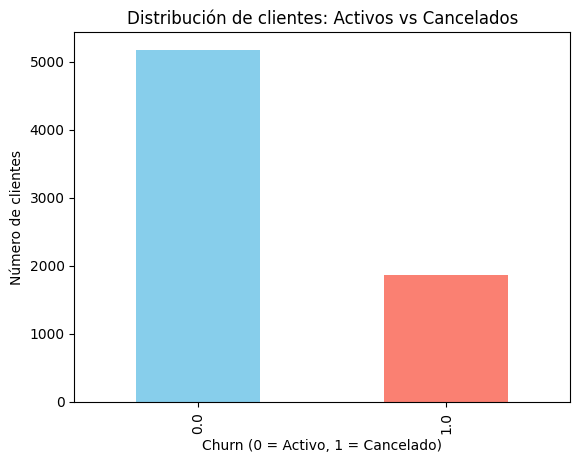

In [17]:
#Revisar la distribución de la variable objetivo (Churn)
churn_counts = df["Churn"].value_counts()
print("Conteo de clases:\n", churn_counts)

#Calcular proporciones
churn_ratio = df["Churn"].value_counts(normalize=True)
print("\nProporción de clases:\n", churn_ratio)

#Visualización rápida
churn_counts.plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Distribución de clientes: Activos vs Cancelados")
plt.xlabel("Churn (0 = Activo, 1 = Cancelado)")
plt.ylabel("Número de clientes")
plt.show()

#### - Normalización 

In [18]:
# Separar variables predictoras y target
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

# --- Opción A: Estandarización (media=0, desviación=1) ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Opción B: Normalización Min-Max (0 a 1) ---
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

#Verificar resultados
print("Estandarización (primeras 5 filas):\n", X_scaled[:5])
print("\nNormalización (primeras 5 filas):\n", X_normalized[:5])


Estandarización (primeras 5 filas):
 [[-0.44073592 -0.95020023  0.02920595 -0.74381819 -1.01148747  1.03230921
   1.52707492  0.3282901  -0.3282901  -0.85405771 -0.88653398 -0.52730575
  -0.52730575 -0.63282108 -0.52730575  1.37918692 -0.52730575 -0.72219538
  -0.52730575  1.56649205 -0.52730575  1.26675155 -0.52730575 -0.79540356
   1.94526822 -0.56172255  0.82806266 -0.52453407 -0.71207515  1.83427494]
 [-0.44073592 -0.95020023 -0.15998997 -0.76625616  0.98864299 -0.968702
  -0.65484672  0.3282901  -0.3282901   1.17088107 -0.88653398 -0.52730575
  -0.52730575 -0.63282108 -0.52730575 -0.72506488 -0.52730575 -0.72219538
  -0.52730575 -0.63836902 -0.52730575 -0.78942078 -0.52730575  1.25722345
  -0.51406793 -0.56172255 -1.20763807 -0.52453407 -0.71207515  1.83427494]
 [-0.44073592 -1.15369976  0.30470177 -0.8815538   0.98864299 -0.968702
  -0.65484672  0.3282901  -0.3282901  -0.85405771  1.12798835 -0.52730575
  -0.52730575 -0.63282108 -0.52730575 -0.72506488 -0.52730575  1.38466685
  -

### Correlación y Seleccion de Variables

#### - Análisis de Correlación

In [ ]:
#Seleccionar solo variables numéricas
numeric_df = df_encoded.select_dtypes(include=["int64", "float64"])

#Calcular la matriz de correlación
corr_matrix = numeric_df.corr()

#Visualizar con un heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

#Revisar correlación con la variable objetivo (Churn)
print("Correlación con Churn:\n", corr_matrix["Churn"].sort_values(ascending=False))
